In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
df = pd.read_csv(r'C:\Users\kashy\OneDrive\Documents\OneDrive\Documents\HR Employee Attrition Analysis\Data\WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
print("=== DATA INFO ===")
df.info()

print("\n=== STATISTICAL SUMMARY ===")
df.describe().round(2)

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [10]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f"\nColumns dropped: {cols_to_drop}")
print(f"New shape: {df.shape}")

df['AttritionBinary'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("\nAttrition value counts:")
print(df['Attrition'].value_counts())
print(f"\nOverall Attrition Rate: {df['AttritionBinary'].mean()*100:.2f}%")

=== MISSING VALUES ===
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRol

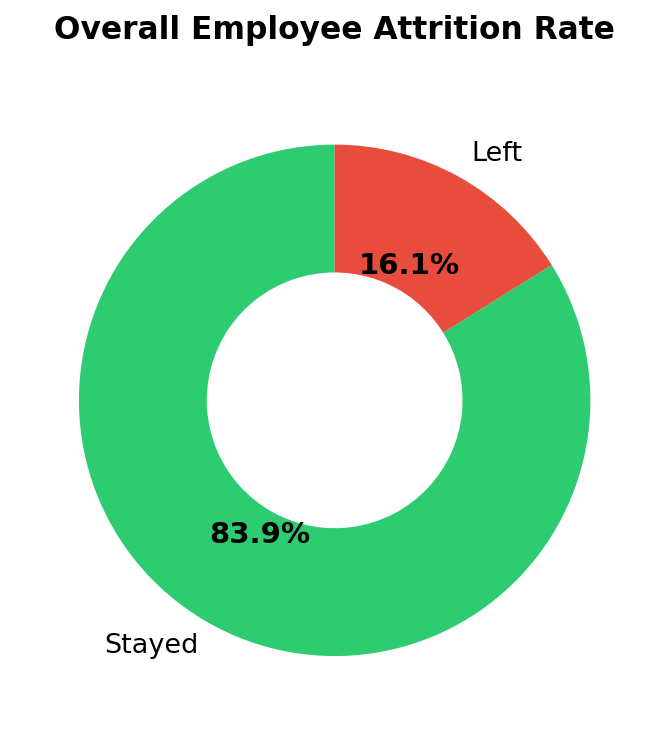

Total Employees: 1470
Employees who left: 237
Employees who stayed: 1233


In [12]:
attrition_counts = df['Attrition'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#2ecc71', '#e74c3c'] 
wedges, texts, autotexts = ax.pie(
    attrition_counts,
    labels=['Stayed', 'Left'],
    autopct='%1.1f%%',          
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 13}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax.set_title('Overall Employee Attrition Rate', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"Total Employees: {len(df)}")
print(f"Employees who left: {attrition_counts['Yes']}")
print(f"Employees who stayed: {attrition_counts['No']}")

               Department  Total_Employees  Employees_Left  Attrition_Rate
2                   Sales              446              92           20.63
0         Human Resources               63              12           19.05
1  Research & Development              961             133           13.84


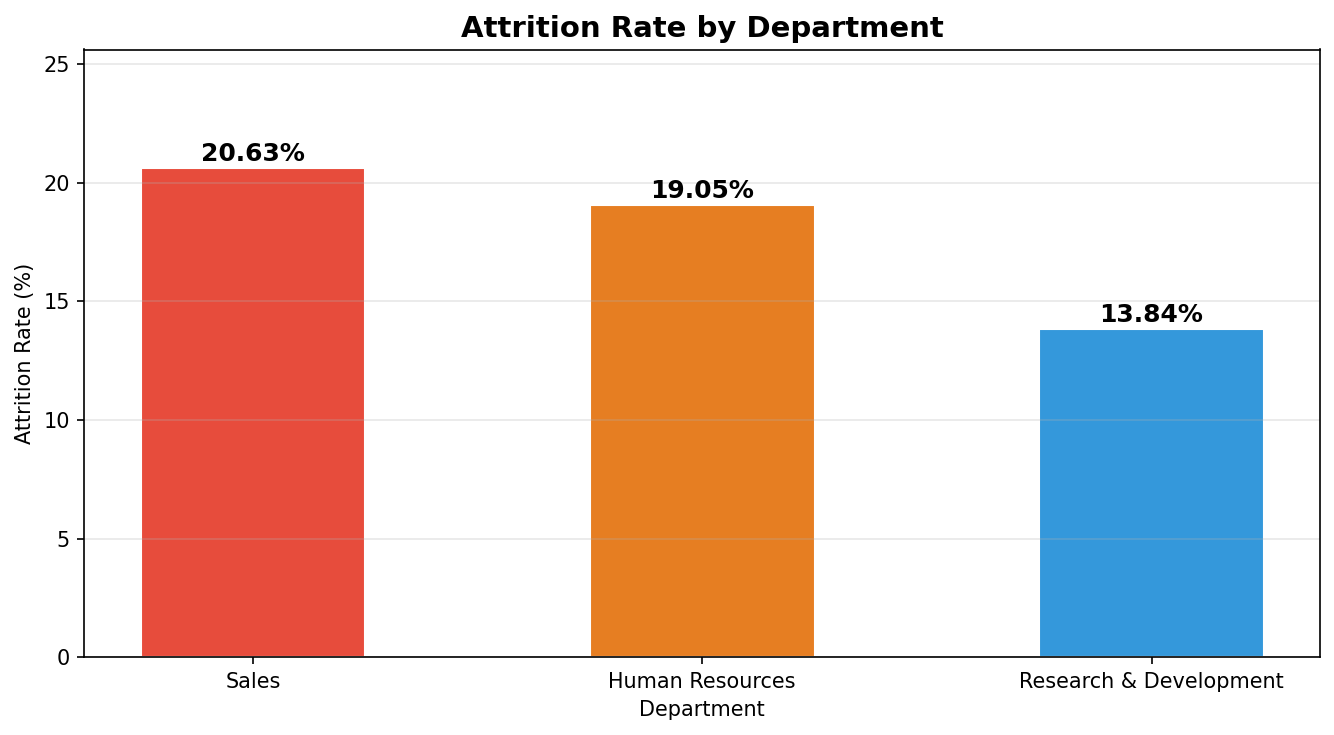

In [14]:
dept_attrition = df.groupby('Department')['AttritionBinary'].agg([
    ('Total_Employees', 'count'),
    ('Employees_Left', 'sum'),
]).reset_index()

dept_attrition['Attrition_Rate'] = (
    dept_attrition['Employees_Left'] / dept_attrition['Total_Employees'] * 100
).round(2)

dept_attrition = dept_attrition.sort_values('Attrition_Rate', ascending=False)

print(dept_attrition)


fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    dept_attrition['Department'],
    dept_attrition['Attrition_Rate'],
    color=['#e74c3c', '#e67e22', '#3498db'],
    edgecolor='white',
    width=0.5
)

for bar, rate in zip(bars, dept_attrition['Attrition_Rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{rate}%',
        ha='center', fontweight='bold', fontsize=12
    )

ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, max(dept_attrition['Attrition_Rate']) + 5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

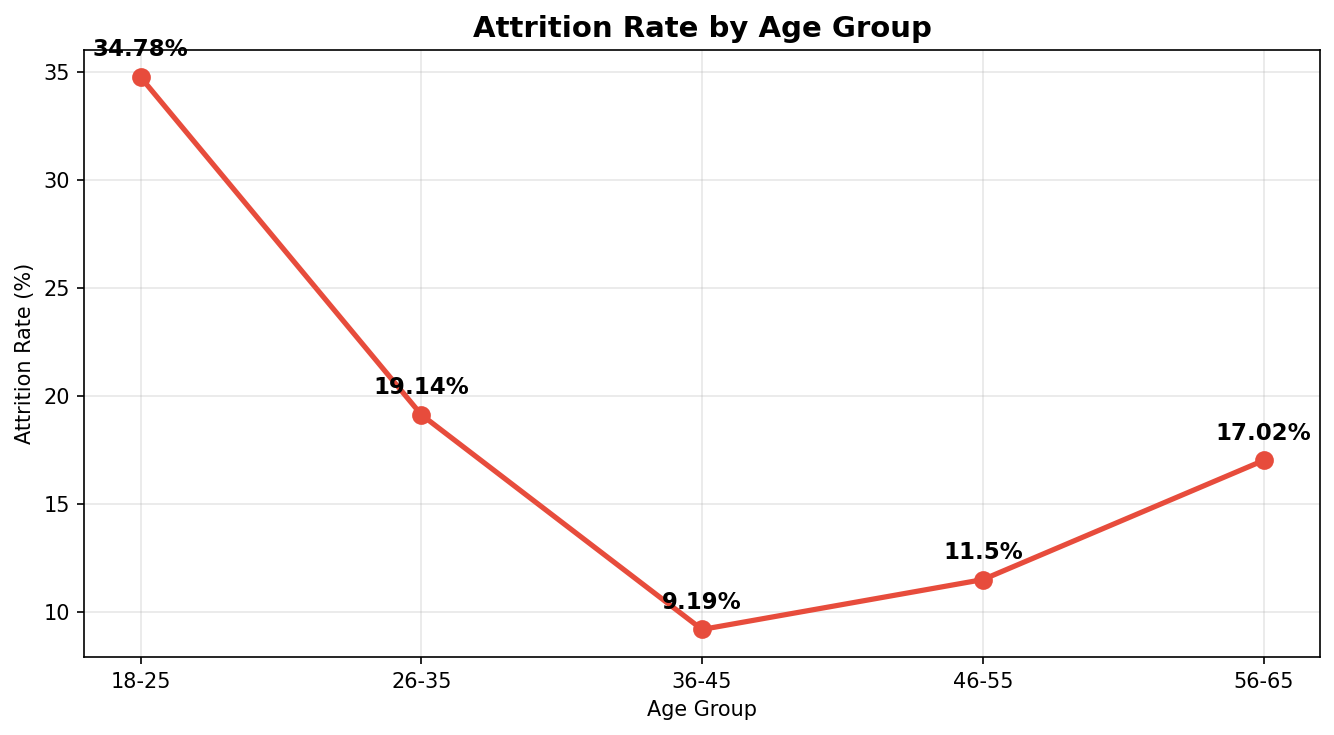

In [16]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=True 
)

age_attrition = df.groupby('AgeGroup', observed=True)['AttritionBinary'].agg([
    ('Total', 'count'),
    ('Left', 'sum')
]).reset_index()

age_attrition['Attrition_Rate'] = (
    age_attrition['Left'] / age_attrition['Total'] * 100
).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    age_attrition['AgeGroup'].astype(str),
    age_attrition['Attrition_Rate'],
    marker='o', linewidth=2.5,
    color='#e74c3c', markersize=8
)

for i, row in age_attrition.iterrows():
    ax.annotate(
        f"{row['Attrition_Rate']}%",
        (str(row['AgeGroup']), row['Attrition_Rate']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Attrition Rate (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

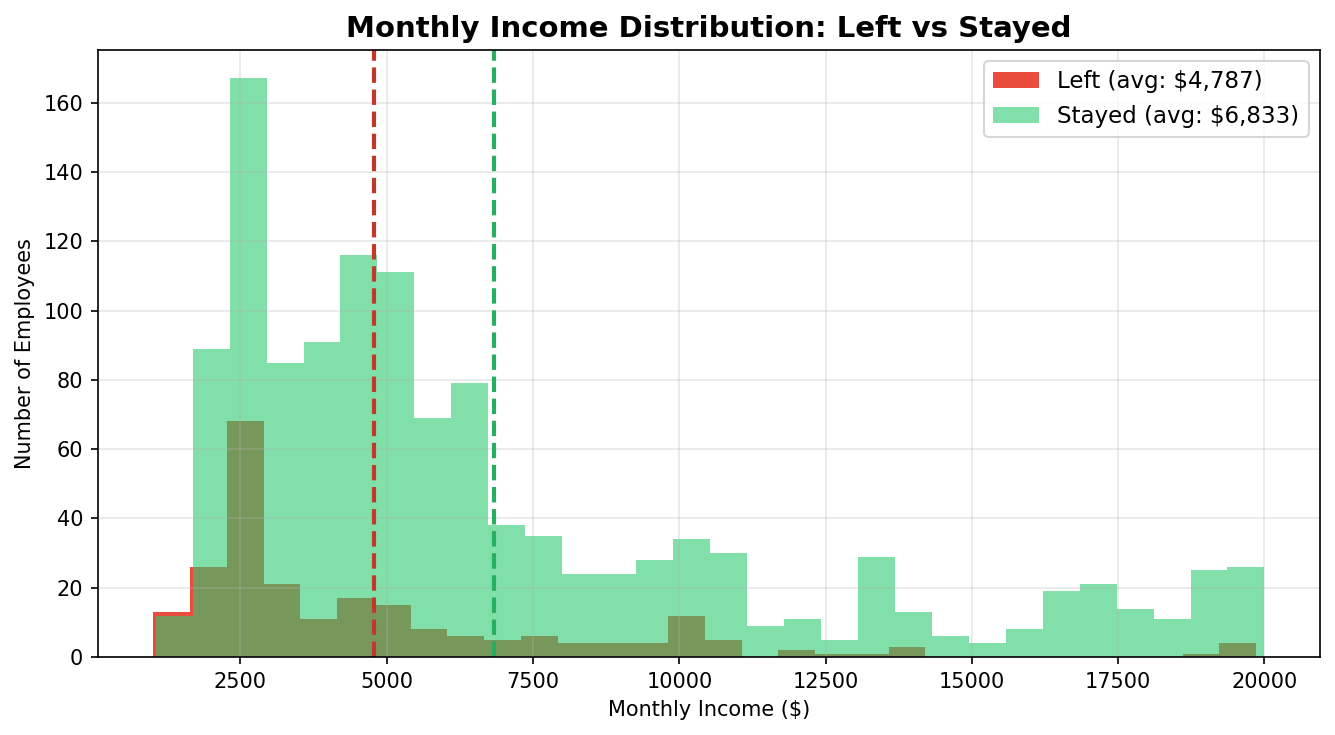

Avg salary of employees who LEFT:   $4,787
Avg salary of employees who STAYED: $6,833
Salary difference: $2,046


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

left = df[df['Attrition'] == 'Yes']['MonthlyIncome']
stayed = df[df['Attrition'] == 'No']['MonthlyIncome']

ax.hist(left, bins=30, alpha=1.0, color='#e74c3c', label=f'Left (avg: ${left.mean():,.0f})')
ax.hist(stayed, bins=30, alpha=0.6, color='#2ecc71', label=f'Stayed (avg: ${stayed.mean():,.0f})')

ax.axvline(left.mean(), color='#c0392b', linestyle='--', linewidth=2)
ax.axvline(stayed.mean(), color='#27ae60', linestyle='--', linewidth=2)

ax.set_title('Monthly Income Distribution: Left vs Stayed', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Income ($)')
ax.set_ylabel('Number of Employees')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Avg salary of employees who LEFT:   ${left.mean():,.0f}")
print(f"Avg salary of employees who STAYED: ${stayed.mean():,.0f}")
print(f"Salary difference: ${stayed.mean() - left.mean():,.0f}")

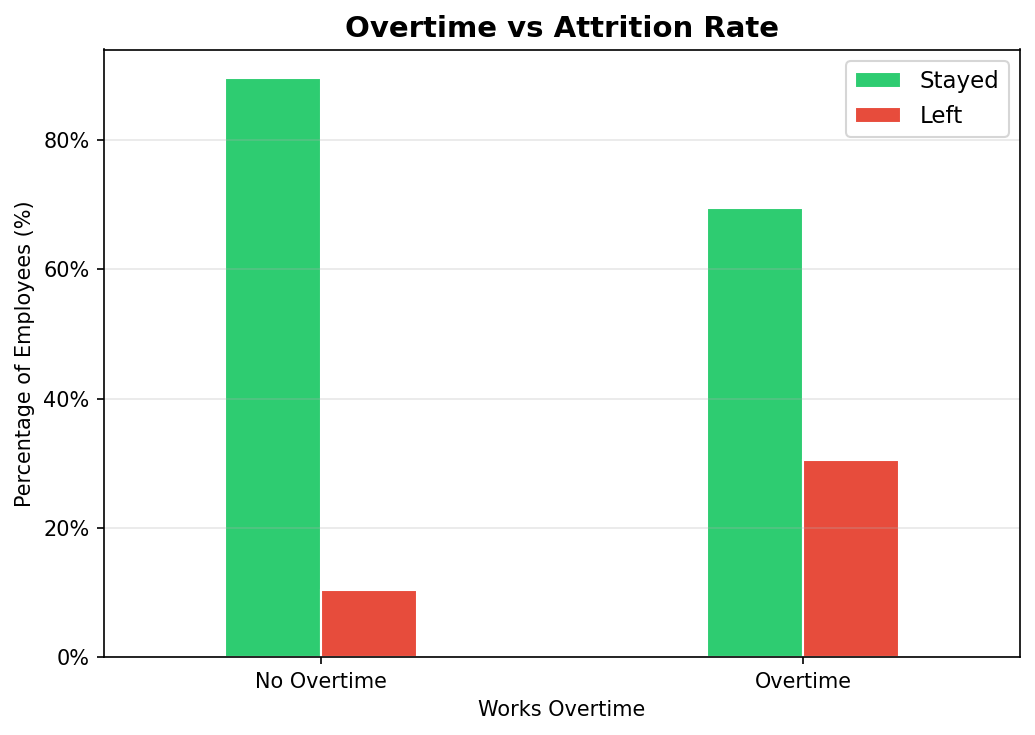

In [22]:
overtime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_pct = overtime_attrition.div(overtime_attrition.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 5))
overtime_pct.plot(
    kind='bar',
    ax=ax,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    width=0.4
)

ax.set_title('Overtime vs Attrition Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Works Overtime')
ax.set_ylabel('Percentage of Employees (%)')
ax.set_xticklabels(['No Overtime', 'Overtime'], rotation=0)
ax.legend(['Stayed', 'Left'], fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== TOP 10 FACTORS CORRELATED WITH ATTRITION ===
TotalWorkingYears      -0.1711
JobLevel               -0.1691
YearsInCurrentRole     -0.1605
MonthlyIncome          -0.1598
Age                    -0.1592
YearsWithCurrManager   -0.1562
StockOptionLevel       -0.1371
YearsAtCompany         -0.1344
JobInvolvement         -0.1300
JobSatisfaction        -0.1035
Name: AttritionBinary, dtype: float64


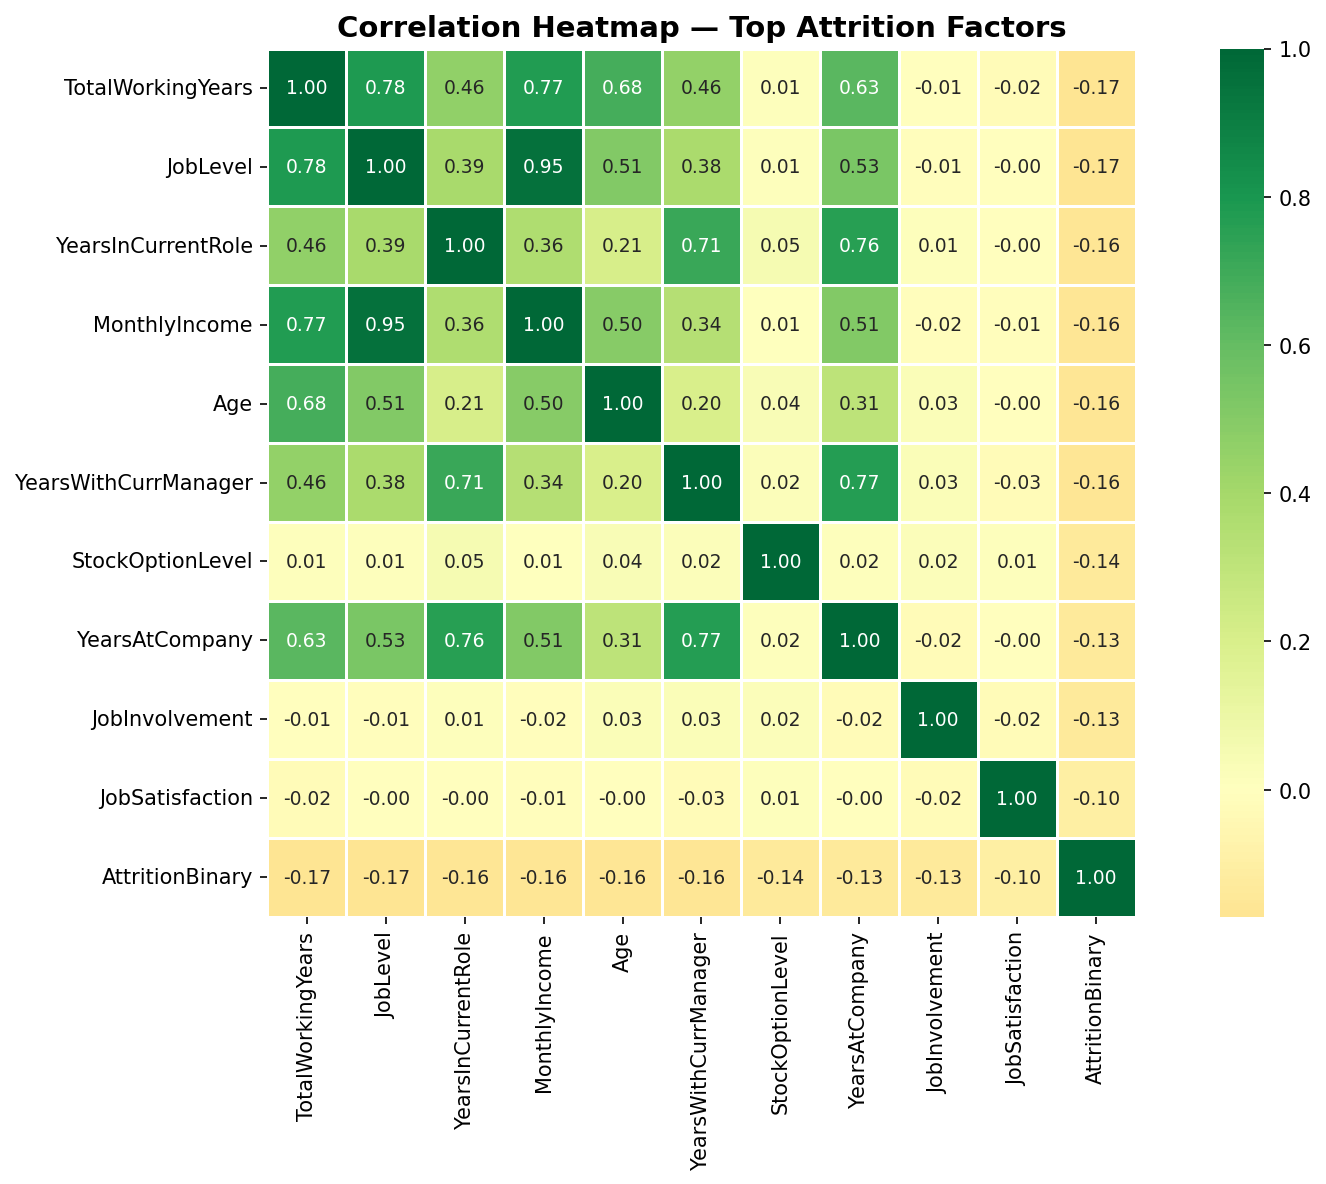

In [23]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = df[numerical_cols].corr()

attrition_corr = corr_matrix['AttritionBinary'].drop('AttritionBinary')
attrition_corr = attrition_corr.sort_values(key=abs, ascending=False).head(10)

print("=== TOP 10 FACTORS CORRELATED WITH ATTRITION ===")
print(attrition_corr.round(4))

top_features = attrition_corr.index.tolist() + ['AttritionBinary']
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Top Attrition Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

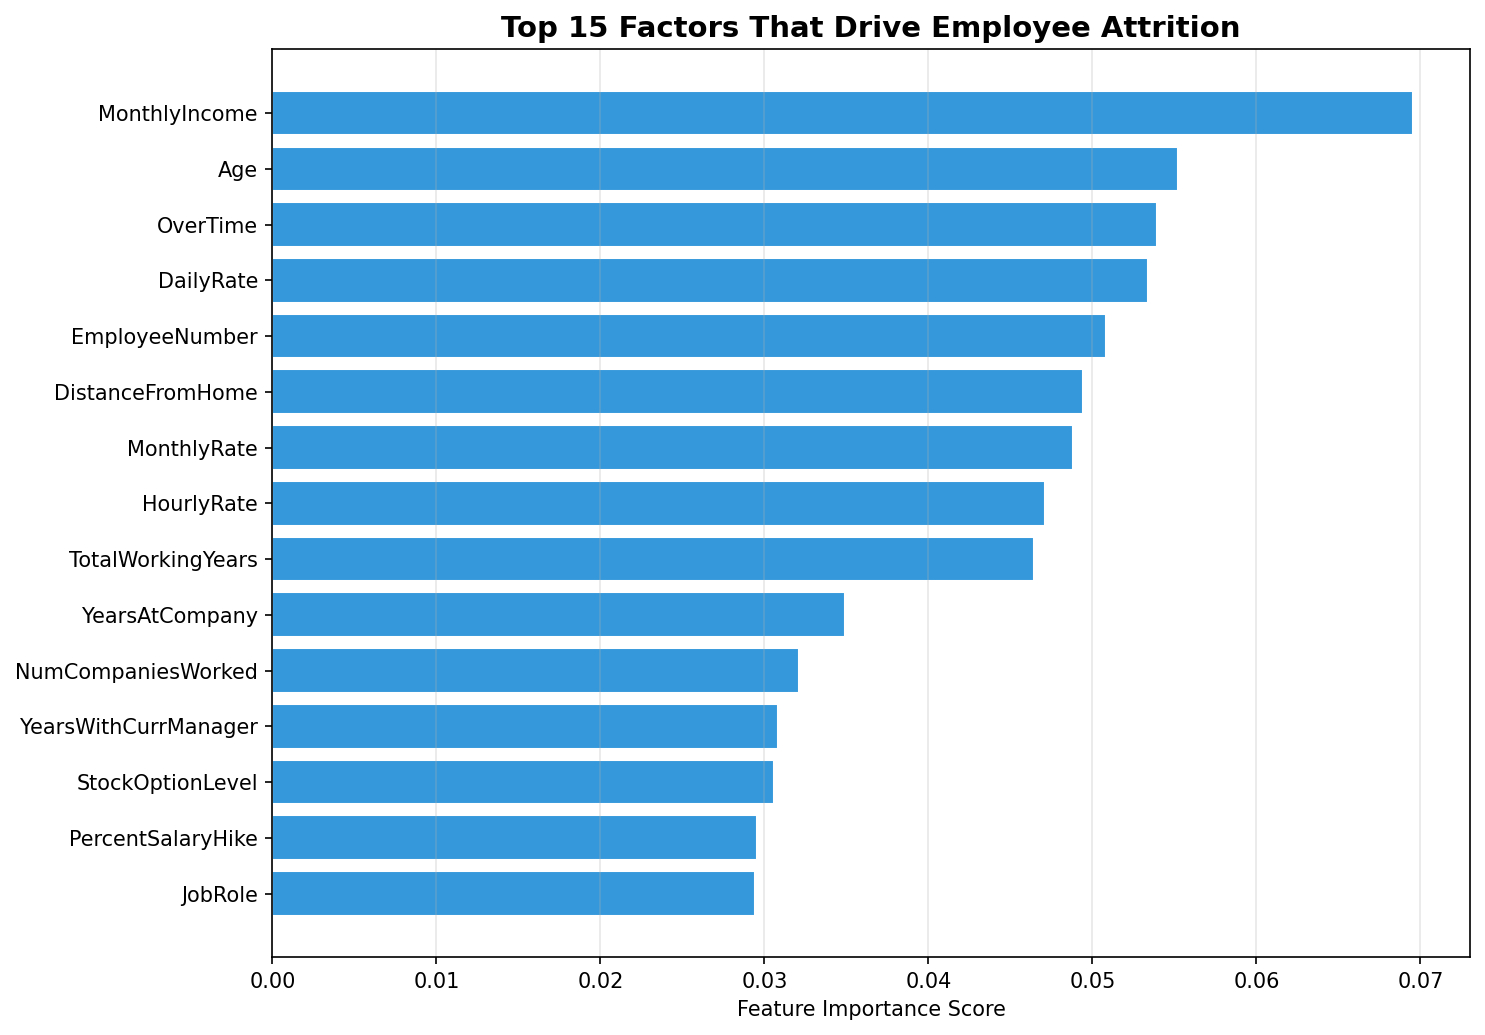

          Feature  Importance
    MonthlyIncome    0.069547
              Age    0.055242
         OverTime    0.053926
        DailyRate    0.053389
   EmployeeNumber    0.050838
 DistanceFromHome    0.049399
      MonthlyRate    0.048834
       HourlyRate    0.047137
TotalWorkingYears    0.046436
   YearsAtCompany    0.034935


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()
le = LabelEncoder()

cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Attrition']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Define features and target
X = df_model.drop(columns=['Attrition', 'AttritionBinary'])
y = df_model['AttritionBinary']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    importance_df['Feature'][::-1],   
    importance_df['Importance'][::-1],
    color='#3498db',
    edgecolor='white'
)
ax.set_title('Top 15 Factors That Drive Employee Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(importance_df.head(10).to_string(index=False))

In [28]:
cols_for_powerbi = [
    'Age', 'AgeGroup', 'Attrition', 'AttritionBinary', 'Department',
    'EducationField', 'Gender', 'JobRole', 'JobLevel', 'JobSatisfaction',
    'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
    'PerformanceRating', 'TotalWorkingYears', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager', 'EnvironmentSatisfaction', 'DistanceFromHome'
]

df_powerbi = df[cols_for_powerbi].copy()

df_powerbi['AgeGroup'] = df_powerbi['AgeGroup'].astype(str)

df_powerbi.to_csv(r'C:\Users\kashy\OneDrive\Documents\OneDrive\Documents\HR Employee Attrition Analysis\Data\hr_Cleaned.csv', index=False)
print(f"Exported {len(df_powerbi)} rows and {len(df_powerbi.columns)} columns to hr_cleaned.csv")
print("\nColumn list:")
print(df_powerbi.columns.tolist())

Exported 1470 rows and 23 columns to hr_cleaned.csv

Column list:
['Age', 'AgeGroup', 'Attrition', 'AttritionBinary', 'Department', 'EducationField', 'Gender', 'JobRole', 'JobLevel', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PerformanceRating', 'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'DistanceFromHome']
